# Phase 2 — scaffolded vs vanilla

A randomised two-arm trial. Both arms play the same Othello rounds with the same
assistant; only a pre-task step differs.

| arm | pre-task step |
|---|---|
| **scaffolded** | contrasting cases (Group A/B), free-text observation, forced choice, correction |
| **vanilla** | matched filler on the warm-up scenario (advice to Julie) |

Both arms pass the same two screens — the prompt task (kept if the panel scores them
BELOW threshold, i.e. non-adopters) and an effort gate on the free-text. Screening is
symmetric by design: if only one arm were gated, an effect could be "we removed the
low-effort people from one arm".

**What each section answers**

- **A** who is in the sample, and where people drop out
- **B** demographics, and whether the arms are balanced
- **C** the manipulation check — did the intervention change how people talk?
- **D** do dialogue acts still predict transfer, as they did in phase 1?
- **E** the primary endpoint — does arm predict transfer?

**Reference values from phase 1** (n=112 with conversation and both solo rounds), for
comparison throughout:

| quantity | phase 1 |
|---|---|
| Solution Request, share of turns | 28.8% |
| Think Aloud, share of turns | 30.4% |
| Think Aloud ~ solo margin | rho +0.356 (p<.001) |
| Solution Request ~ solo margin | rho -0.216 (p .022) |
| solo margin sum | mean -14.1, sd 11.9 |

In [804]:
import pandas
scores = pandas.read_csv("scores.csv")

## 0. Setup

In [805]:
import glob, json, os, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

BASE = Path.cwd()
REC = BASE / "recordings-download"
SOLO = ["pb220260706", "pbg20260726"]       # unassisted rounds -> the outcome
AI_ROUND = "poc20260727"

# Phase-1 reference values, for comparison only. Measured on 112 participants with a
# conversation and both solo rounds.
P1 = {"SolReq": 28.8, "ThinkAloud": 30.4, "rho_TA": 0.356, "rho_SR": -0.216,
      "margin_mean": -14.1, "margin_sd": 11.9}

# Eligibility on AI usage: non-adopters only, i.e. NOT more than a few times a week.
# Collected on the FINAL demographics page, after the post-survey, so asking it cannot
# prime behaviour during the game.
#
# Conditioning on it is legitimate even though it is measured late: AI usage frequency
# is a stable trait that a 20-minute study cannot change, so it is a baseline covariate
# measured out of order -- not a post-treatment variable like the assisted-round margin,
# where conditioning would open a collider. The criterion is fixed here, in advance, and
# applied identically to both arms.
GENAI_EXCLUDE = {"daily", "several_times_day"}
# GENAI_EXCLUDE = {"several_times_day"}
# GENAI_EXCLUDE = {}

ACTS = ["Solution Request", "Think Aloud", "Knowledge Deficit Question",
        "Common Ground Question", "Conversational Acknowledgment", "Metacomment"]
SHORT = {"Solution Request": "SolReq", "Think Aloud": "ThinkAloud",
         "Knowledge Deficit Question": "KDQ", "Common Ground Question": "CGQ",
         "Conversational Acknowledgment": "ConvAck", "Metacomment": "Metacomment"}

In [806]:
def solo_margin(d: Path):
    '''Sum of final_margin over the two unassisted rounds; None if either is missing.'''
    tot = 0
    for pz in SOLO:
        f = d / f"oth_score_{pz}.json"
        if not f.exists():
            return None
        v = json.load(open(f)).get("final_margin")
        if v is None:
            return None
        tot += v
    return float(tot)

def assisted_margin(d: Path):
    '''Sum of final_margin over the two unassisted rounds; None if either is missing.'''
    f = d / f"oth_score_{AI_ROUND}.json"
    if not f.exists():
        return None
    v = json.load(open(f)).get("final_margin")
    if v is None:
        return None
    return float(v)


def load():
    '''One row per participant directory, complete or not.

    Rows are kept even when incomplete so section A can show the funnel -- filtering to
    completers here would hide where people drop out.
    '''
    rows = []
    for d in sorted(REC.iterdir()):
        if not d.is_dir():
            continue
        arm = ("scaffolded" if (d / "intervention.json").exists()
               else "vanilla" if (d / "filler.json").exists() else None)
        dem = json.load(open(d / "demographics.json")) if (d / "demographics.json").exists() else {}
        pt = json.load(open(d / "prompt_task.json")) if (d / "prompt_task.json").exists() else {}
        iv = {}
        for f in ("intervention.json", "filler.json"):
            if (d / f).exists():
                iv = json.load(open(d / f))
        ann = sorted(d.glob(f"annotated_conversation_{AI_ROUND}.jsonl"))
        acts, n_turns = Counter(), 0
        for fp in ann:
            for line in open(fp):
                if not line.strip():
                    continue
                t = json.loads(line)
                a = t.get("annotation_user")
                if not a or not (t.get("user") or "").strip():
                    continue
                n_turns += 1
                acts.update(set(a.get("final") or []))
        row = dict(pid=d.name, arm=arm, n_turns=n_turns,
                   margin=solo_margin(d),
                   assisted_margin=assisted_margin(d),
                   genai=dem.get("genai_usage"), skill=dem.get("skill_rating"),
                   age=dem.get("age"), education=dem.get("education"),
                   prompt_rule=pt.get("rule"), prompt_kept=pt.get("passed"),
                   prompt_mean=pt.get("mean_score"), prompt_median=pt.get("median_score"),
                   variant=iv.get("variant"), choice=iv.get("choice"),
                   choice_correct=iv.get("choice_correct"),
                   effort=(iv.get("effort") or {}).get("median_score"))
        for a in ACTS:
            row[SHORT[a]] = 100.0 * acts[a] / n_turns if n_turns else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

df = load()
df = df.loc[(df["variant"] == "v2_think_pair") | (df["arm"] == "vanilla")]
df["complete"] = df.n_turns.gt(0) & df.margin.notna()
# NaN genai = never reached the final demographics page (dropout), not a heavy user.
df["genai_eligible"] = ~df.genai.isin(GENAI_EXCLUDE)
# Carry-over cohort: re-recruited from earlier studies with SKIP_PROMPT_TASK=1, so they
# never wrote a prompt in this study. EXCLUDED from the primary analysis.
#
# The ground for exclusion is procedural -- they received a different protocol, missing a
# stage the others completed -- not that their numbers came out wrong. That distinction
# matters: a protocol-based exclusion is defensible stated in advance, an outcome-based
# one is not. Recorded here rather than applied by hand so it cannot drift.
#
# It is also not cosmetic. With them pooled in, the Solution Request contrast reads
# -7.2 points (p .73); among fresh participants alone it is -10.7 and Think Aloud +26.8.
# The carry-over cohort shows no effect on either act.
df["carryover"] = df.prompt_rule.eq("carried over from phase 1")
df["analysed"] = (df.complete & df.genai_eligible & df.genai.notna()
                  & ~df.carryover)
# df["analysed"] = (df.complete & df.genai_eligible & df.genai.notna())
print(f"{len(df)} participant directories | {int(df.complete.sum())} complete "
      f"(conversation + both solo rounds) | {int(df.analysed.sum())} also "
      f"AI-usage eligible")
print(df.groupby("arm", dropna=False).agg(n=("pid", "size"),
                                          complete=("complete", "sum")).to_string())

74 participant directories | 63 complete (conversation + both solo rounds) | 33 also AI-usage eligible
             n  complete
arm                     
scaffolded  28        25
vanilla     46        38


## A. Sample and funnel

Where participants stop. `arm = None` means they never reached the pre-task step, so
they were screened out at eligibility or the prompt task, or abandoned early.

In [807]:
stages = [
    ("started (directory exists)", df.pid.notna()),
    ("reached prompt task",        df.prompt_rule.notna()),
    ("kept by prompt task",        df.prompt_kept == True),
    ("assigned to an arm",         df.arm.notna()),
    ("has a conversation",         df.n_turns > 0),
    ("completed both solo rounds", df.margin.notna()),
]
prev = None
print(f"{'stage':<34}{'n':>5}{'kept from previous':>20}")
for name, mask in stages:
    n = int(mask.sum())
    frac = "" if prev in (None, 0) else f"{100*n/prev:>18.0f}%"
    print(f"{name:<34}{n:>5}{frac:>20}")
    prev = n

print("\nprompt-task rule in force (a mid-collection change is visible here):")
print(df.prompt_rule.value_counts(dropna=False).to_string())
print("\nintervention variant seen (scaffolded only):")
print(df.variant.value_counts(dropna=False).to_string())
print("\ncohort (carry-over is EXCLUDED from the analysis set):")
_c = df.groupby(df.carryover.map({True: "carry-over", False: "fresh"}), dropna=False)
print(_c.agg(n=("pid", "size"), complete=("complete", "sum"),
             analysed=("analysed", "sum")).to_string())


stage                                 n  kept from previous
started (directory exists)           74                    
reached prompt task                  74                100%
kept by prompt task                  63                 85%
assigned to an arm                   74                117%
has a conversation                   65                 88%
completed both solo rounds           63                 97%

prompt-task rule in force (a mid-collection change is visible here):
prompt_rule
mean                         62
carried over from phase 1    12

intervention variant seen (scaffolded only):
variant
NaN              46
v2_think_pair    28

cohort (carry-over is EXCLUDED from the analysis set):
             n  complete  analysed
carryover                         
carry-over  12        10         0
fresh       62        53        33


## B. Demographics

`genai_usage` is only recorded once a participant reaches the demographics page, so it
is missing for anyone who dropped earlier -- that is dropout, not missing data.

Worth watching: the prompt-task screen selects for weak prompt CONSTRUCTION, which is
not the same as low AI usage. If completers span the full usage range, "non-adopter"
would be the wrong label for the population.

In [808]:
comp = df[df.complete]
ORDER = ["never", "less_than_monthly", "about_monthly", "few_times_month", "weekly",
         "few_times_week", "daily", "several_times_day"]

def dist(series, order=None):
    c = series.value_counts(dropna=False)
    keys = [k for k in (order or []) if k in c.index] + \
           [k for k in c.index if not order or k not in order]
    return pd.DataFrame({"n": [c[k] for k in keys]}, index=[str(k) for k in keys])

for col, order in (("genai", ORDER), ("skill", None), ("education", None), ("age", None)):
    if comp[col].notna().sum() == 0:
        continue
    print(f"\n--- {col} (completers, n={len(comp)}) ---")
    print(dist(comp[col], order).to_string())

print("\n\n--- AI-usage eligibility (non-adopters only) ---")
seen = comp[comp.genai.notna()]
if len(seen):
    excl = seen.genai.isin(GENAI_EXCLUDE)
    print(f"{len(seen)} completers reached final demographics; "
          f"{int(excl.sum())} excluded ({100*excl.mean():.0f}%) as "
          f"{sorted(GENAI_EXCLUDE)}")
    print(pd.crosstab(seen.genai, seen.arm, dropna=False).to_string())
    print("\nphase-1 reference: 35% of those reaching demographics were daily or "
          "several-times-daily users.")
else:
    print("no completers have reached final demographics yet")

print("\n\n--- arm balance among completers ---")
for col in ("genai", "skill"):
    if comp[col].notna().sum() == 0:
        continue
    tab = pd.crosstab(comp[col], comp["arm"], dropna=False)
    print(f"\n{col}:")
    print(tab.to_string())


--- genai (completers, n=63) ---
                    n
never               4
less_than_monthly   5
about_monthly       4
few_times_month    12
weekly              5
few_times_week      6
daily               5
several_times_day   7
nan                15

--- skill (completers, n=63) ---
            n
1          18
2          18
dont_know  15
3           5
4           4
5           3

--- education (completers, n=63) ---
                n
bachelors      19
nan            15
some_college    8
postgrad        6
associate       6
hs_graduate     5
some_postgrad   2
less_than_hs    1
hs_incomplete   1

--- age (completers, n=63) ---
       n
nan   15
34.0   4
44.0   3
23.0   3
40.0   2
39.0   2
52.0   2
35.0   2
31.0   2
20.0   2
55.0   2
21.0   2
19.0   2
56.0   2
64.0   2
46.0   1
63.0   1
32.0   1
33.0   1
30.0   1
70.0   1
37.0   1
47.0   1
27.0   1
26.0   1
22.0   1
59.0   1
57.0   1
62.0   1
48.0   1
18.0   1


--- AI-usage eligibility (non-adopters only) ---
48 completers reached fin

## C. Manipulation check

The primary question at small n. If the arms do not differ here, nothing downstream can
work, and the intervention needs fixing before more participants are spent.

Pre-specified direction: **Solution Request down**, **Think Aloud up** in scaffolded.
`words` is a guard -- phase 1 showed message length predicts transfer only through Think
Aloud, dropping to nothing once it is controlled, so an arm that only writes more has
not been manipulated in the way that matters.

In [809]:
def words_per_msg(pid):
    d = REC / pid
    fs = sorted(d.glob(f"conversation_{AI_ROUND}.jsonl"))
    if not fs:
        return np.nan
    lens = [len((json.loads(l).get("user") or "").split())
            for l in open(fs[0]) if l.strip()]
    lens = [x for x in lens if x]
    return float(np.mean(lens)) if lens else np.nan

# Sections C-E use the ANALYSIS set: complete AND AI-usage eligible. Swap to
# df[df.complete] to see the unrestricted sample -- worth doing once, to check the
# exclusion is not doing the work.
comp = df[df.analysed].copy()
comp["words"] = [words_per_msg(p) for p in comp.pid]

cols = [SHORT[a] for a in ACTS] + ["words", "n_turns"]
print(f"per-arm means (n scaffolded={int((comp.arm=='scaffolded').sum())}, "
      f"vanilla={int((comp.arm=='vanilla').sum())})\n")
tab = comp.groupby("arm")[cols].mean().T
tab["difference"] = tab.get("scaffolded", np.nan) - tab.get("vanilla", np.nan)
tab["phase 1"] = [P1.get(c, np.nan) for c in tab.index]
print(tab.to_string(float_format=lambda v: f"{v:8.1f}"))

print("\nMann-Whitney per act (two-sided; underpowered until n is well past 20/arm):")
print(f"{'measure':<14}{'scaffolded':>12}{'vanilla':>10}{'diff':>9}{'p':>9}")
for c in cols:
    s = comp.loc[comp.arm == "scaffolded", c].dropna()
    v = comp.loc[comp.arm == "vanilla", c].dropna()
    if len(s) < 2 or len(v) < 2:
        continue
    try:
        p = stats.mannwhitneyu(s, v).pvalue
    except ValueError:
        p = np.nan
    print(f"{c:<14}{s.mean():>12.1f}{v.mean():>10.1f}{s.mean()-v.mean():>+9.1f}{p:>9.3f}")

per-arm means (n scaffolded=11, vanilla=22)

arm          scaffolded  vanilla  difference  phase 1
SolReq             38.2     43.1        -4.9     28.8
ThinkAloud         33.2     16.0        17.2     30.4
KDQ                 8.5     17.8        -9.3      NaN
CGQ                27.9     26.9         0.9      NaN
ConvAck            18.2     11.4         6.8      NaN
Metacomment         3.3     11.1        -7.8      NaN
words               7.2      6.1         1.2      NaN
n_turns             4.8      4.9        -0.1      NaN

Mann-Whitney per act (two-sided; underpowered until n is well past 20/arm):
measure         scaffolded   vanilla     diff        p
SolReq                38.2      43.1     -4.9    0.685
ThinkAloud            33.2      16.0    +17.2    0.195
KDQ                    8.5      17.8     -9.3    0.194
CGQ                   27.9      26.9     +0.9    0.857
ConvAck               18.2      11.4     +6.8    0.517
Metacomment            3.3      11.1     -7.8    0.172
words  

### C2. Comprehension, scaffolded only

`choice_correct` records whether the participant picked Group B before being corrected.
It is an objective comprehension measure needing no coding, and a natural third tier
between intention-to-treat and per-protocol: someone who misread the contrast cannot
have applied it.

A high rate of incorrect choices means the material is not legible enough -- better to
learn that at n=20 than n=200.

In [810]:
sc = df[(df.arm == "scaffolded") & df.choice.notna()]
if len(sc):
    print(f"{len(sc)} scaffolded participants reached the forced choice")
    print(sc.groupby("variant").choice_correct.agg(["size", "sum", "mean"])
          .rename(columns={"size": "n", "sum": "correct", "mean": "rate"})
          .to_string(float_format=lambda v: f"{v:.2f}"))
    done = sc[sc.complete]
    if len(done) >= 4 and done.choice_correct.nunique() > 1:
        print("\nacts by whether they read the contrast correctly:")
        print(done.groupby("choice_correct")[["SolReq", "ThinkAloud"]].mean()
              .to_string(float_format=lambda v: f"{v:6.1f}"))
else:
    print("no scaffolded participants with a recorded choice yet")

28 scaffolded participants reached the forced choice
                n correct rate
variant                       
v2_think_pair  28      20 0.71

acts by whether they read the contrast correctly:
                SolReq  ThinkAloud
choice_correct                    
False             78.6        14.3
True              39.1        22.7


## D. Do dialogue acts still predict transfer?

Phase 1 found Think Aloud +0.356 and Solution Request -0.216 against the solo margin
sum. Whether that replicates in this population is the assumption the whole intervention
rests on -- if it does not, teaching people to talk differently cannot help even if the
manipulation works perfectly.

This is **observational within the trial**: act rates are not randomised, so these carry
the same confounding as phase 1. The randomised quantity is section E.

In [811]:
comp = df[df.analysed].copy()
n = len(comp)
crit = stats.t.ppf(0.975, max(n - 2, 1))
floor = crit / np.sqrt(max(n - 2, 1) + crit ** 2)
print(f"n={n} complete   margin mean {comp.margin.mean():+.1f}  "
      f"sd {comp.margin.std(ddof=1):.1f}   (phase 1: {P1['margin_mean']:+.1f} / "
      f"{P1['margin_sd']:.1f})")
print(f"smallest |rho| reaching p<.05 at this n: {floor:.3f}\n")
print(f"{'act':<14}{'rho':>8}{'p':>9}{'phase 1':>10}{'same sign':>11}")
for a in ACTS:
    c = SHORT[a]
    x = comp[c].dropna()
    if x.std() == 0 or len(x) < 4:
        print(f"{c:<14}{'--':>8}{'no variance / too few':>20}")
        continue
    r, p = stats.spearmanr(comp.loc[x.index, c], comp.loc[x.index, "margin"])
    ref = P1.get("rho_TA") if c == "ThinkAloud" else (P1.get("rho_SR") if c == "SolReq" else np.nan)
    same = "" if np.isnan(ref) else ("yes" if np.sign(r) == np.sign(ref) else "NO")
    print(f"{c:<14}{r:>8.3f}{p:>9.3f}{ref if not np.isnan(ref) else float('nan'):>10.3f}{same:>11}")

for target, ref in (("ThinkAloud", P1["rho_TA"]), ("SolReq", P1["rho_SR"])):
    need = int(((1.96 + 0.84) / np.arctanh(abs(ref))) ** 2 + 3)
    print(f"\nn to detect phase 1's {target} rho of {ref:+.3f} at 80% power: ~{need}")

n=33 complete   margin mean -14.0  sd 13.8   (phase 1: -14.1 / 11.9)
smallest |rho| reaching p<.05 at this n: 0.344

act                rho        p   phase 1  same sign
SolReq          -0.129    0.476    -0.216        yes
ThinkAloud      -0.025    0.888     0.356         NO
KDQ              0.044    0.809       nan           
CGQ              0.294    0.097       nan           
ConvAck         -0.076    0.675       nan           
Metacomment     -0.179    0.318       nan           

n to detect phase 1's ThinkAloud rho of +0.356 at 80% power: ~59

n to detect phase 1's SolReq rho of -0.216 at 80% power: ~165


### D2. Spontaneous vs coached — does the act still work when it is taught?

The intervention assumes an act that *predicts* transfer will still predict it once
participants are coached into producing it. That does not follow. An act can be a
**marker** of something useful (a participant who already reasons this way) rather than
a **lever** on it, in which case teaching the surface form moves the label without
moving the mechanism.

There is a precedent in this project. In the simulator's `gate-require_kdq` arm the act
was forced by a classifier: its rate rose from 9% to 65%, and the link it was supposed to
carry collapsed — Board Report given a Knowledge Deficit Question fell from 86% to 47%.
Same act by the label, different thing underneath.

The arms give a natural test, because Think Aloud is **spontaneous in vanilla** and
**coached in scaffolded**. If it is a lever, the two slopes should look alike. If it is a
marker, the coached slope flattens.

This is descriptive until the arms are well past 30 each — the interaction term is the
lowest-powered quantity in the notebook. It is here so the comparison is pre-specified
rather than discovered later.

In [812]:
def spontaneous_vs_coached(d, act, outcome="margin"):
    sub = d.dropna(subset=[outcome, act])
    out = []
    for arm, kind in (("vanilla", "spontaneous"), ("scaffolded", "coached")):
        a = sub[sub.arm == arm]
        if len(a) < 4 or a[act].std() == 0:
            out.append((arm, kind, len(a), np.nan, np.nan, np.nan))
            continue
        r, p = stats.spearmanr(a[act], a[outcome])
        b = sm.OLS(a[outcome], sm.add_constant(a[[act]])).fit()
        out.append((arm, kind, len(a), r, p, b.params[act]))
    return sub, pd.DataFrame(out, columns=["arm", "kind", "n", "rho", "p", "slope"])


for act in ("ThinkAloud", "SolReq"):
    sub, t = spontaneous_vs_coached(df[df.analysed], act)
    r_all, p_all = stats.spearmanr(sub[act], sub.margin)
    ref = P1.get("rho_TA") if act == "ThinkAloud" else P1.get("rho_SR")
    print(f"\n{'=' * 74}\n{act} vs solo margin   (pooled rho {r_all:+.3f}, p {p_all:.3f}"
          f" | phase 1 {ref:+.3f})\n{'=' * 74}")
    print(t.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

    # Does the slope differ by arm? Negative interaction = the coached version is flatter.
    s2 = sub.copy()
    s2["sc"] = (s2.arm == "scaffolded").astype(int)
    s2["inter"] = s2[act] * s2.sc
    if s2.sc.nunique() > 1 and len(s2) >= 8:
        m = sm.OLS(s2.margin, sm.add_constant(s2[[act, "sc", "inter"]])).fit()
        print(f"\n  interaction {act} x scaffolded: {m.params['inter']:+.3f} "
              f"(se {m.bse['inter']:.3f}, p {m.pvalues['inter']:.3f})")
        print(f"  negative => the coached version of {act} is flatter, i.e. a marker "
              f"rather than a lever")
        n_arm = int(min(s2.sc.sum(), (1 - s2.sc).sum()))
        print(f"  smallest arm n = {n_arm}; treat as descriptive below ~30/arm")


ThinkAloud vs solo margin   (pooled rho -0.025, p 0.888 | phase 1 +0.356)
       arm        kind  n      rho        p    slope
   vanilla spontaneous 22    0.108    0.632   -0.009
scaffolded     coached 11   -0.251    0.457   -0.012

  interaction ThinkAloud x scaffolded: -0.003 (se 0.177, p 0.986)
  negative => the coached version of ThinkAloud is flatter, i.e. a marker rather than a lever
  smallest arm n = 11; treat as descriptive below ~30/arm

SolReq vs solo margin   (pooled rho -0.129, p 0.476 | phase 1 -0.216)
       arm        kind  n      rho        p    slope
   vanilla spontaneous 22   -0.002    0.994   -0.012
scaffolded     coached 11   -0.449    0.165   -0.120

  interaction SolReq x scaffolded: -0.108 (se 0.153, p 0.487)
  negative => the coached version of SolReq is flatter, i.e. a marker rather than a lever
  smallest arm n = 11; treat as descriptive below ~30/arm


**Reading it.** Compare the two `slope` values, which are in margin points per
percentage point of the act. A coached slope near zero while the spontaneous slope is
positive is the marker pattern, and it would mean the intervention can raise the act
without raising transfer — the manipulation working while the mechanism does not.

It would also explain a pooled correlation that *falls* as the sample grows: adding
scaffolded participants, whose act is coached and inert, dilutes an estimate that the
vanilla participants alone would support.

If that is what the data shows at adequate n, the implication is not that the
intervention failed but that Think Aloud is the wrong target — and Solution Request,
which is about **removing** a behaviour rather than installing one, is less exposed to
this failure mode. Removing a behaviour has no coached-form problem: the participant
either asks for the answer or does not.

## E. Primary endpoint — arm vs transfer

The randomised comparison. Expect this to be uninformative for a long time: at phase 1's
margin sd of 11.9 and a target of d=0.3, it needs roughly **175 per arm**.

Reported anyway so the number is never a surprise, and so a catastrophic reversal would
be visible early.

In [813]:
comp = df[df.analysed]
s = comp.loc[comp.arm == "scaffolded", "margin"].dropna()
v = comp.loc[comp.arm == "vanilla", "margin"].dropna()
print(f"scaffolded n={len(s)}  mean {s.mean():+.1f}" if len(s) else "scaffolded n=0")
print(f"vanilla    n={len(v)}  mean {v.mean():+.1f}" if len(v) else "vanilla n=0")
if len(s) >= 2 and len(v) >= 2:
    d = (s.mean() - v.mean()) / np.sqrt(((len(s)-1)*s.var() + (len(v)-1)*v.var())
                                        / max(len(s)+len(v)-2, 1))
    print(f"\ndifference {s.mean()-v.mean():+.1f}   Cohen's d {d:+.2f}")
    print(f"Mann-Whitney p {stats.mannwhitneyu(s, v).pvalue:.3f}")
    for target_d in (0.3, 0.4, 0.5):
        per = int(np.ceil(2 * ((1.96 + 0.84) / target_d) ** 2))
        print(f"  n/arm for d={target_d}: {per}")
else:
    print("\nnot enough completers in both arms yet")

scaffolded n=11  mean -17.8
vanilla    n=22  mean -12.1

difference -5.7   Cohen's d -0.42
Mann-Whitney p 0.266
  n/arm for d=0.3: 175
  n/arm for d=0.4: 98
  n/arm for d=0.5: 63


## What about R1 Scores

In [814]:
comp = df[df.analysed]
s = comp.loc[comp.arm == "scaffolded", "assisted_margin"].dropna()
v = comp.loc[comp.arm == "vanilla", "assisted_margin"].dropna()
print(f"scaffolded n={len(s)}  mean {s.mean():+.1f}" if len(s) else "scaffolded n=0")
print(f"vanilla    n={len(v)}  mean {v.mean():+.1f}" if len(v) else "vanilla n=0")
if len(s) >= 2 and len(v) >= 2:
    d = (s.mean() - v.mean()) / np.sqrt(((len(s)-1)*s.var() + (len(v)-1)*v.var())
                                        / max(len(s)+len(v)-2, 1))
    print(f"\ndifference {s.mean()-v.mean():+.1f}   Cohen's d {d:+.2f}")
    print(f"Mann-Whitney p {stats.mannwhitneyu(s, v).pvalue:.3f}")
    for target_d in (0.3, 0.4, 0.5):
        per = int(np.ceil(2 * ((1.96 + 0.84) / target_d) ** 2))
        print(f"  n/arm for d={target_d}: {per}")
else:
    print("\nnot enough completers in both arms yet")

scaffolded n=11  mean -5.8
vanilla    n=22  mean -7.5

difference +1.7   Cohen's d +0.10
Mann-Whitney p 0.451
  n/arm for d=0.3: 175
  n/arm for d=0.4: 98
  n/arm for d=0.5: 63


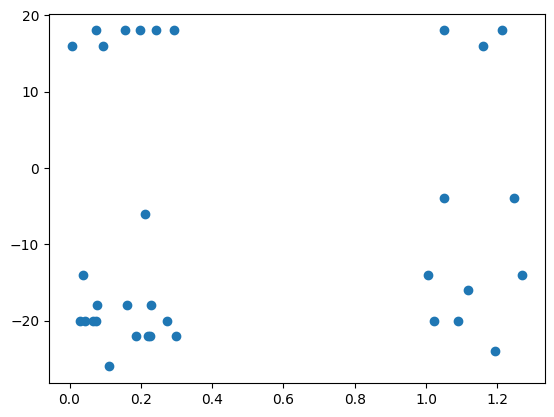

In [815]:
import matplotlib.pyplot as plt
import random
x_coords = [0] * len(v) + [1] * len(s)
x_coords = [x_coords[i] + random.random() * 0.3 for i in range(len(x_coords))]
plt.scatter(x_coords, v.to_list() + s.to_list())

## Reading order as the sample fills

1. **C first, always.** If Solution Request and Think Aloud do not separate, fix the
   material rather than collecting more.
2. **C2 next.** A low correct-choice rate means the contrast is not legible; that is a
   material problem, not a sample-size problem.
3. **D at around n=60**, where phase 1's Think Aloud correlation becomes detectable.
4. **E last**, near n=175/arm. Reading it earlier invites over-interpreting noise.